Day 80 Param Sangani T-test Handwash Data



# Setup and Context

<img src="https://i.imgur.com/gugIA5r.png" width=700>

### Introduction

Dr Ignaz Semmelweis was a Hungarian physician born in 1818 who worked in the Vienna General Hospital. In the past people thought of illness as caused by "bad air" or evil spirits. But in the 1800s Doctors started looking more at anatomy, doing autopsies and started making arguments based on data. Dr Semmelweis suspected that something was going wrong with the procedures at Vienna General Hospital. Semmelweis wanted to figure out why so many women in maternity wards were dying from childbed fever (i.e., [puerperal fever](https://en.wikipedia.org/wiki/Postpartum_infections)).

<img src=https://i.imgur.com/lSyNUwR.png width=700>

Today you will become Dr Semmelweis. This is your office 👆. You will step into Dr Semmelweis' shoes and analyse the same data collected from 1841 to 1849.

### The Data Source

Dr Semmelweis published his research in 1861. I found the scanned pages of the [full text with the original tables in German](http://www.deutschestextarchiv.de/book/show/semmelweis_kindbettfieber_1861), but an excellent [English translation can be found here](http://graphics8.nytimes.com/images/blogs/freakonomics/pdf/the%20etiology,%20concept%20and%20prophylaxis%20of%20childbed%20fever.pdf).

<img src=https://i.imgur.com/6HfLtaC.png width=500>

### Upgrade plotly (only Google Colab Notebook)

Google Colab may not be running the latest version of plotly. If you're working in Google Colab, uncomment the line below, run the cell, and restart your notebook server.

In [1]:
# %pip install --upgrade plotly

### Import Statements

In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

### Notebook Presentation

In [3]:
pd.options.display.float_format = '{:,.2f}'.format

# Create locators for ticks on the time axis


from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

### Read the Data

In [4]:
df_yearly = pd.read_csv('annual_deaths_by_clinic.csv')
# parse_dates avoids DateTime conversion later
df_monthly = pd.read_csv('monthly_deaths.csv',
                      parse_dates=['date'])

# Preliminary Data Exploration

**Challenge**: Check out these two DataFrames ☝️.
* What is the shape of df_yearly and df_monthly? How many rows and columns?
* What are the column names?
* Which years are included in the dataset?
* Are there any NaN values or duplicates?
* What were the average number of births that took place per month?
* What were the average number of deaths that took place per month?

In [5]:
print('df_yearly shape:', df_yearly.shape)
print('df_monthly shape:', df_monthly.shape)

print('\n--- df_yearly info ---')
print(df_yearly.info())
print('\n--- df_monthly info ---')
print(df_monthly.info())

print('\n--- df_yearly columns ---')
print(df_yearly.columns)
print('\n--- df_monthly columns ---')
print(df_monthly.columns)

print('\n--- Years in df_yearly ---')
print(df_yearly['year'].unique())
print('\n--- Years in df_monthly ---')
# Extract year from the 'date' column in df_monthly
print(df_monthly['date'].dt.year.unique())

print('\n--- NaN values in df_yearly ---')
print(df_yearly.isnull().sum())
print('\n--- NaN values in df_monthly ---')
print(df_monthly.isnull().sum())

print('\n--- Duplicates in df_yearly ---')
print(df_yearly.duplicated().sum())
print('\n--- Duplicates in df_monthly ---')
print(df_monthly.duplicated().sum())

print('\n--- Average births and deaths per month (from df_monthly) ---')
print(f"Average births per month: {df_monthly['births'].mean():.2f}")
print(f"Average deaths per month: {df_monthly['deaths'].mean():.2f}")

df_yearly shape: (12, 4)
df_monthly shape: (98, 3)

--- df_yearly info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   year    12 non-null     int64 
 1   births  12 non-null     int64 
 2   deaths  12 non-null     int64 
 3   clinic  12 non-null     object
dtypes: int64(3), object(1)
memory usage: 516.0+ bytes
None

--- df_monthly info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    98 non-null     datetime64[ns]
 1   births  98 non-null     int64         
 2   deaths  98 non-null     int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 2.4 KB
None

--- df_yearly columns ---
Index(['year', 'births', 'deaths', 'clinic'], dtype='object')

--- df_monthly columns ---
Index(['date', 'birth

### Percentage of Women Dying in Childbirth

**Challenge**: How dangerous was childbirth in the 1840s in Vienna?

* Using the annual data, calculate the percentage of women giving birth who died throughout the 1840s at the hospital.


In comparison, the United States recorded 18.5 maternal deaths per 100,000 or 0.018% in 2013 [(source).](
https://en.wikipedia.org/wiki/Maternal_death#:~:text=The%20US%20has%20the%20%22highest,17.8%20per%20100%2C000%20in%202009)

In [6]:
total_births_yearly = df_yearly['births'].sum()
total_deaths_yearly = df_yearly['deaths'].sum()

pct_deaths_yearly = (total_deaths_yearly / total_births_yearly) * 100

print(f"Total births in the 1840s: {total_births_yearly:,.0f}")
print(f"Total deaths in the 1840s: {total_deaths_yearly:,.0f}")
print(f"Percentage of women dying in childbirth (1840s): {pct_deaths_yearly:.2f}%")

Total births in the 1840s: 37,833
Total deaths in the 1840s: 2,680
Percentage of women dying in childbirth (1840s): 7.08%


# Visualise the Total Number of Births 🤱 and Deaths 💀 over Time

### Plot the Monthly Data on Twin Axes

**Challenge**: Create a [Matplotlib chart](https://matplotlib.org/3.3.2/api/_as_gen/matplotlib.pyplot.plot.html) with twin y-axes. It should look something like this:

<img src=https://i.imgur.com/F9DOJxx.png width=700>

* Format the x-axis using locators for the years and months (Hint: we did this in the Google Trends notebook)
* Set the range on the x-axis so that the chart lines touch the y-axes
* Add gridlines
* Use `skyblue` and `crimson` for the line colours
* Use a dashed line style for the number of deaths
* Change the line thickness to 3 and 2 for the births and deaths respectively.
* Do you notice anything in the late 1840s?

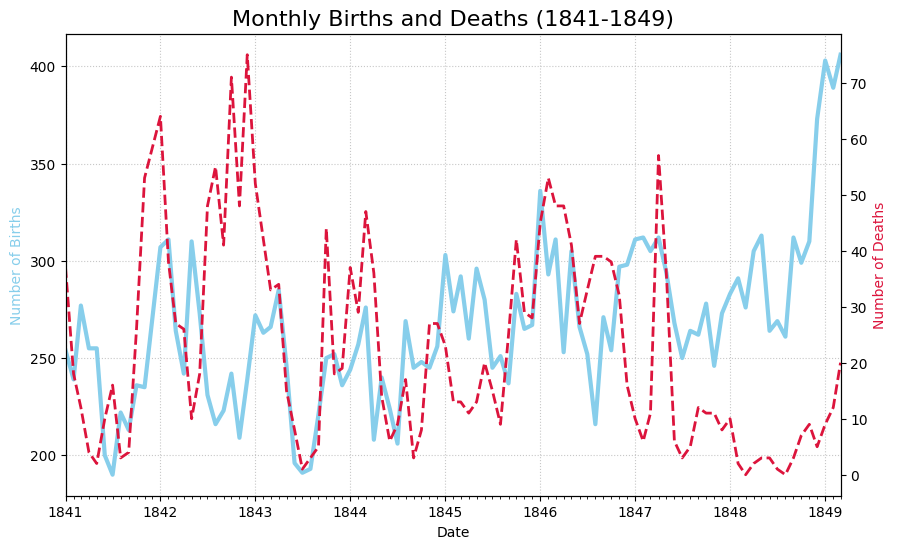

In [7]:
plt.figure(figsize=(10, 6), dpi=100)

ax1 = plt.gca() # Get the current axes
ax2 = ax1.twinx() # Create a twin axis

# Plotting births on ax1
ax1.plot(df_monthly['date'], df_monthly['births'], color='skyblue', linewidth=3, label='Births')

# Plotting deaths on ax2
ax2.plot(df_monthly['date'], df_monthly['deaths'], color='crimson', linestyle='--', linewidth=2, label='Deaths')

# X-axis formatting
ax1.set_xlabel('Date')
ax1.set_ylabel('Number of Births', color='skyblue')
ax2.set_ylabel('Number of Deaths', color='crimson')

# Set x-axis limits to make lines touch y-axes
ax1.set_xlim(df_monthly['date'].min(), df_monthly['date'].max())

# Locators for x-axis
years = mdates.YearLocator()
months = mdates.MonthLocator()
year_fmt = mdates.DateFormatter('%Y')
month_fmt = mdates.DateFormatter('%b')

ax1.xaxis.set_major_locator(years)
ax1.xaxis.set_major_formatter(year_fmt)
ax1.xaxis.set_minor_locator(months)

# Add gridlines
ax1.grid(True, linestyle=':', alpha=0.7)

# Add title
plt.title('Monthly Births and Deaths (1841-1849)', fontsize=16)

# Show plot
plt.show()

# The Yearly Data Split by Clinic

Now let's look at the annual data instead.

**Challenge**: Use plotly to create line charts of the births and deaths of the two different clinics at the Vienna General Hospital.
* Which clinic is bigger or more busy judging by the number of births?
* Has the hospital had more patients over time?
* What was the highest number of deaths recorded in clinic 1 and clinic 2?

In [8]:
fig_births = px.line(df_yearly, x='year', y='births', color='clinic',
                   title='Annual Births in Clinic 1 and Clinic 2')
fig_births.show()

fig_deaths = px.line(df_yearly, x='year', y='deaths', color='clinic',
                   title='Annual Deaths in Clinic 1 and Clinic 2')
fig_deaths.show()


print('\n--- Analysis of Clinics ---')

# Which clinic is bigger or more busy judging by the number of births?
# This can be seen visually from the chart, but we can also sum them.
total_births_by_clinic = df_yearly.groupby('clinic')['births'].sum()
print(f"Total births per clinic:\n{total_births_by_clinic}")
if total_births_by_clinic['clinic 1'] > total_births_by_clinic['clinic 2']:
    print("Clinic 1 generally seems to be busier (has more births).")
else:
    print("Clinic 2 generally seems to be busier (has more births).")

# Has the hospital had more patients over time?
# This can be inferred from the trend of the birth lines in the chart.
# Let's check the first and last year's total births.
first_year_births = df_yearly[df_yearly['year'] == df_yearly['year'].min()]['births'].sum()
last_year_births = df_yearly[df_yearly['year'] == df_yearly['year'].max()]['births'].sum()
print(f"\nTotal births in {df_yearly['year'].min()}: {first_year_births:,}")
print(f"Total births in {df_yearly['year'].max()}: {last_year_births:,}")
if last_year_births > first_year_births:
    print("Yes, the hospital generally had more patients (births) over time.")
else:
    print("No, the hospital generally had fewer patients (births) over time.")

# What was the highest number of deaths recorded in clinic 1 and clinic 2?
highest_deaths_clinic1 = df_yearly[df_yearly['clinic'] == 'clinic 1']['deaths'].max()
highest_deaths_clinic2 = df_yearly[df_yearly['clinic'] == 'clinic 2']['deaths'].max()
print(f"\nHighest deaths in Clinic 1: {highest_deaths_clinic1:,}")
print(f"Highest deaths in Clinic 2: {highest_deaths_clinic2:,}")


--- Analysis of Clinics ---
Total births per clinic:
clinic
clinic 1    20042
clinic 2    17791
Name: births, dtype: int64
Clinic 1 generally seems to be busier (has more births).

Total births in 1841: 5,478
Total births in 1846: 7,764
Yes, the hospital generally had more patients (births) over time.

Highest deaths in Clinic 1: 518
Highest deaths in Clinic 2: 202


### Calculate the Proportion of Deaths at Each Clinic

**Challenge**: Calculate the proportion of maternal deaths per clinic. That way we can compare like with like.
* Work out the percentage of deaths for each row in the `df_yearly` DataFrame by adding a column called "pct_deaths".
* Calculate the average maternal death rate for clinic 1 and clinic 2 (i.e., the total number of deaths per the total number of births).
* Create another plotly line chart to see how the percentage varies year over year with the two different clinics.
* Which clinic has a higher proportion of deaths?
* What is the highest monthly death rate in clinic 1 compared to clinic 2?

In [9]:
# Work out the percentage of deaths for each row in the df_yearly DataFrame
df_yearly['pct_deaths'] = (df_yearly['deaths'] / df_yearly['births']) * 100

print('df_yearly with pct_deaths column:')
print(df_yearly.head())

# Calculate the average maternal death rate for clinic 1 and clinic 2
average_death_rate_clinic1 = df_yearly[df_yearly['clinic'] == 'clinic 1']['pct_deaths'].mean()
average_death_rate_clinic2 = df_yearly[df_yearly['clinic'] == 'clinic 2']['pct_deaths'].mean()

print(f"\nAverage maternal death rate for Clinic 1: {average_death_rate_clinic1:.2f}%")
print(f"Average maternal death rate for Clinic 2: {average_death_rate_clinic2:.2f}%")

# Create another plotly line chart to see how the percentage varies year over year
fig_pct_deaths = px.line(df_yearly, x='year', y='pct_deaths', color='clinic',
                        title='Percentage of Maternal Deaths per Clinic (Yearly)')
fig_pct_deaths.show()

# Which clinic has a higher proportion of deaths?
if average_death_rate_clinic1 > average_death_rate_clinic2:
    print("\nClinic 1 has a higher average proportion of deaths.")
else:
    print("\nClinic 2 has a higher average proportion of deaths.")

# What is the highest yearly death rate in clinic 1 compared to clinic 2?
highest_pct_deaths_clinic1 = df_yearly[df_yearly['clinic'] == 'clinic 1']['pct_deaths'].max()
highest_pct_deaths_clinic2 = df_yearly[df_yearly['clinic'] == 'clinic 2']['pct_deaths'].max()

print(f"Highest yearly death rate in Clinic 1: {highest_pct_deaths_clinic1:.2f}%")
print(f"Highest yearly death rate in Clinic 2: {highest_pct_deaths_clinic2:.2f}%")

df_yearly with pct_deaths column:
   year  births  deaths    clinic  pct_deaths
0  1841    3036     237  clinic 1        7.81
1  1842    3287     518  clinic 1       15.76
2  1843    3060     274  clinic 1        8.95
3  1844    3157     260  clinic 1        8.24
4  1845    3492     241  clinic 1        6.90

Average maternal death rate for Clinic 1: 9.85%
Average maternal death rate for Clinic 2: 4.04%



Clinic 1 has a higher average proportion of deaths.
Highest yearly death rate in Clinic 1: 15.76%
Highest yearly death rate in Clinic 2: 7.60%


# The Effect of Handwashing

Dr Semmelweis made handwashing obligatory in the summer of 1947. In fact, he ordered people to wash their hands with clorine (instead of water).

In [10]:
# Date when handwashing was made mandatory
handwashing_start = pd.to_datetime('1847-06-01')

**Challenge**:
* Add a column called "pct_deaths" to `df_monthly` that has the percentage of deaths per birth for each row.
* Create two subsets from the `df_monthly` data: before and after Dr Semmelweis ordered washing hand.
* Calculate the average death rate prior to June 1947.
* Calculate the average death rate after June 1947.

In [11]:
# Add a column called 'pct_deaths' to df_monthly
df_monthly['pct_deaths'] = (df_monthly['deaths'] / df_monthly['births']) * 100

print('df_monthly with pct_deaths column:')
print(df_monthly.head())

# Create two subsets from the df_monthly data: before and after Dr Semmelweis ordered washing hand.
df_before_handwashing = df_monthly[df_monthly['date'] < handwashing_start]
df_after_handwashing = df_monthly[df_monthly['date'] >= handwashing_start]

print(f"\nData points before handwashing: {len(df_before_handwashing)}")
print(f"Data points after handwashing: {len(df_after_handwashing)}")

# Calculate the average death rate prior to June 1947.
average_death_rate_before = df_before_handwashing['pct_deaths'].mean()
print(f"\nAverage death rate before handwashing: {average_death_rate_before:.2f}%")

# Calculate the average death rate after June 1947.
average_death_rate_after = df_after_handwashing['pct_deaths'].mean()
print(f"Average death rate after handwashing: {average_death_rate_after:.2f}%")

df_monthly with pct_deaths column:
        date  births  deaths  pct_deaths
0 1841-01-01     254      37       14.57
1 1841-02-01     239      18        7.53
2 1841-03-01     277      12        4.33
3 1841-04-01     255       4        1.57
4 1841-05-01     255       2        0.78

Data points before handwashing: 76
Data points after handwashing: 22

Average death rate before handwashing: 10.50%
Average death rate after handwashing: 2.11%


### Calculate a Rolling Average of the Death Rate

**Challenge**: Create a DataFrame that has the 6 month rolling average death rate prior to mandatory handwashing.

*Hint*: You'll need to set the dates as the index in order to avoid the date column being dropped during the calculation.

In [12]:
df_rolling_avg = df_before_handwashing.set_index('date').rolling(window=6)['pct_deaths'].mean().reset_index()
print("DataFrame with 6-month rolling average death rate (before handwashing):")
print(df_rolling_avg.head(10))

DataFrame with 6-month rolling average death rate (before handwashing):
        date  pct_deaths
0 1841-01-01         NaN
1 1841-02-01         NaN
2 1841-03-01         NaN
3 1841-04-01         NaN
4 1841-05-01         NaN
5 1841-06-01        5.63
6 1841-07-01        4.61
7 1841-08-01        3.58
8 1841-09-01        3.17
9 1841-10-01        4.74


### Highlighting Subsections of a Line Chart

**Challenge**: Copy-paste and then modify the Matplotlib chart from before to plot the monthly death rates (instead of the total number of births and deaths). The chart should look something like this:

<img src=https://i.imgur.com/X6TQe0R.png width=500>

* Add 3 seperate lines to the plot: the death rate before handwashing, after handwashing, and the 6-month moving average before handwashing.
* Show the monthly death rate before handwashing as a thin dashed black line.
* Show the moving average as a thicker, crimon line.
* Show the rate after handwashing as a skyblue line with round markers.
* Look at the [code snippet in the documentation to see how you can add a legend](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.legend.html) to the chart.

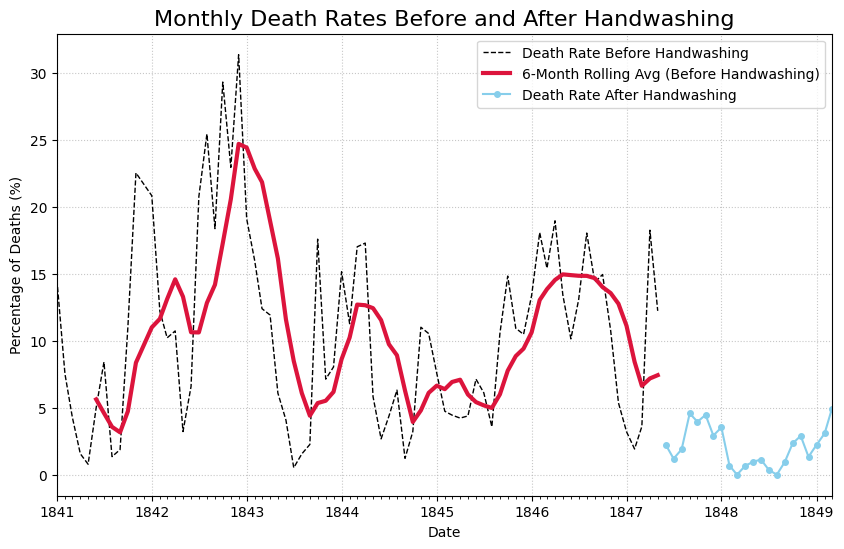

In [13]:
plt.figure(figsize=(10, 6), dpi=100)

ax = plt.gca() # Get the current axes

# Plotting death rate before handwashing
plt.plot(df_before_handwashing['date'], df_before_handwashing['pct_deaths'],
         color='black', linestyle='--', linewidth=1, label='Death Rate Before Handwashing')

# Plotting 6-month rolling average before handwashing
plt.plot(df_rolling_avg['date'], df_rolling_avg['pct_deaths'],
         color='crimson', linestyle='-', linewidth=3, label='6-Month Rolling Avg (Before Handwashing)')

# Plotting death rate after handwashing
plt.plot(df_after_handwashing['date'], df_after_handwashing['pct_deaths'],
         color='skyblue', linestyle='-', marker='o', markersize=4, label='Death Rate After Handwashing')

# X-axis formatting
ax.set_xlabel('Date')
ax.set_ylabel('Percentage of Deaths (%)')

# Set x-axis limits to make lines touch y-axes
ax.set_xlim(df_monthly['date'].min(), df_monthly['date'].max())

# Locators for x-axis
years = mdates.YearLocator()
months = mdates.MonthLocator()
year_fmt = mdates.DateFormatter('%Y')
month_fmt = mdates.DateFormatter('%b')

ax.xaxis.set_major_locator(years)
ax.xaxis.set_major_formatter(year_fmt)
ax.xaxis.set_minor_locator(months)

# Add gridlines
ax.grid(True, linestyle=':', alpha=0.7)

# Add title
plt.title('Monthly Death Rates Before and After Handwashing', fontsize=16)

# Add legend
plt.legend()

# Show plot
plt.show()

### Statistics - Calculate the Difference in the Average Monthly Death Rate

**Challenge**:
* What was the average percentage of monthly deaths before handwashing?
* What was the average percentage of monthly deaths after handwashing was made obligatory?
* By how much did handwashing reduce the average chance of dying in childbirth in percentage terms?
* How do these numbers compare to the average for all the 1840s that we calculated earlier?
* How many times lower are the chances of dying after handwashing compared to before?

In [14]:
print(f"Average percentage of monthly deaths before handwashing: {average_death_rate_before:.2f}%")
print(f"Average percentage of monthly deaths after handwashing: {average_death_rate_after:.2f}%")

reduction_pct = average_death_rate_before - average_death_rate_after
print(f"Handwashing reduced the average chance of dying by: {reduction_pct:.2f} percentage points.")

print(f"\nOverall death rate for all the 1840s (yearly data): {pct_deaths_yearly:.2f}%")
print(f"The average monthly death rate before handwashing ({average_death_rate_before:.2f}%) was higher than the overall 1840s average ({pct_deaths_yearly:.2f}%).")
print(f"The average monthly death rate after handwashing ({average_death_rate_after:.2f}%) was significantly lower than the overall 1840s average ({pct_deaths_yearly:.2f}%).")

times_lower = average_death_rate_before / average_death_rate_after
print(f"\nThe chances of dying after handwashing were approximately {times_lower:.2f} times lower compared to before handwashing.")

Average percentage of monthly deaths before handwashing: 10.50%
Average percentage of monthly deaths after handwashing: 2.11%
Handwashing reduced the average chance of dying by: 8.40 percentage points.

Overall death rate for all the 1840s (yearly data): 7.08%
The average monthly death rate before handwashing (10.50%) was higher than the overall 1840s average (7.08%).
The average monthly death rate after handwashing (2.11%) was significantly lower than the overall 1840s average (7.08%).

The chances of dying after handwashing were approximately 4.98 times lower compared to before handwashing.


### Use Box Plots to Show How the Death Rate Changed Before and After Handwashing

**Challenge**:
* Use [NumPy's `.where()` function](https://numpy.org/doc/stable/reference/generated/numpy.where.html) to add a column to `df_monthly` that shows if a particular date was before or after the start of handwashing.
* Then use plotly to create box plot of the data before and after handwashing.
* How did key statistics like the mean, max, min, 1st and 3rd quartile changed as a result of the new policy?



In [15]:
df_monthly['handwashing_era'] = np.where(df_monthly['date'] < handwashing_start, 'Before Handwashing', 'After Handwashing')

fig = px.box(df_monthly, x='handwashing_era', y='pct_deaths',
             title='Monthly Death Rate Before and After Handwashing',
             labels={'handwashing_era': 'Period', 'pct_deaths': 'Percentage of Deaths (%)'})
fig.show()

print("\nDescriptive statistics for monthly death rates before and after handwashing:")
print(df_monthly.groupby('handwashing_era')['pct_deaths'].describe())


Descriptive statistics for monthly death rates before and after handwashing:
                    count  mean  std  min  25%   50%   75%   max
handwashing_era                                                 
After Handwashing   22.00  2.11 1.52 0.00 0.96  2.06  3.05  4.93
Before Handwashing  76.00 10.50 7.07 0.52 4.39 10.52 15.01 31.38


### Use Histograms to Visualise the Monthly Distribution of Outcomes

**Challenge**: Create a [plotly histogram](https://plotly.com/python/histograms/) to show the monthly percentage of deaths.

* Use docs to check out the available parameters. Use the [`color` parameter](https://plotly.github.io/plotly.py-docs/generated/plotly.express.histogram.html) to display two overlapping histograms.
* The time period of handwashing is shorter than not handwashing. Change `histnorm` to `percent` to make the time periods comparable.
* Make the histograms slighlty transparent
* Experiment with the number of bins on the histogram. Which number work well in communicating the range of outcomes?
* Just for fun, display your box plot on the top of the histogram using the `marginal` parameter.

In [16]:
fig = px.histogram(df_monthly,
                   x='pct_deaths',
                   color='handwashing_era',
                   marginal='box',
                   histnorm='percent',
                   opacity=0.6,
                   nbins=30, # Experiment with this number
                   title='Distribution of Monthly Death Rates Before and After Handwashing',
                   labels={'pct_deaths': 'Percentage of Deaths (%)'})

fig.update_layout(barmode='overlay') # Overlap histograms
fig.show()

### Use a Kernel Density Estimate (KDE) to visualise a smooth distribution

**Challenge**: Use [Seaborn's `.kdeplot()`](https://seaborn.pydata.org/generated/seaborn.kdeplot.html) to create two kernel density estimates of the `pct_deaths`, one for before handwashing and one for after.

* Use the `shade` parameter to give your two distributions different colours.
* What weakness in the chart do you see when you just use the default parameters?
* Use the `clip` parameter to address the problem.


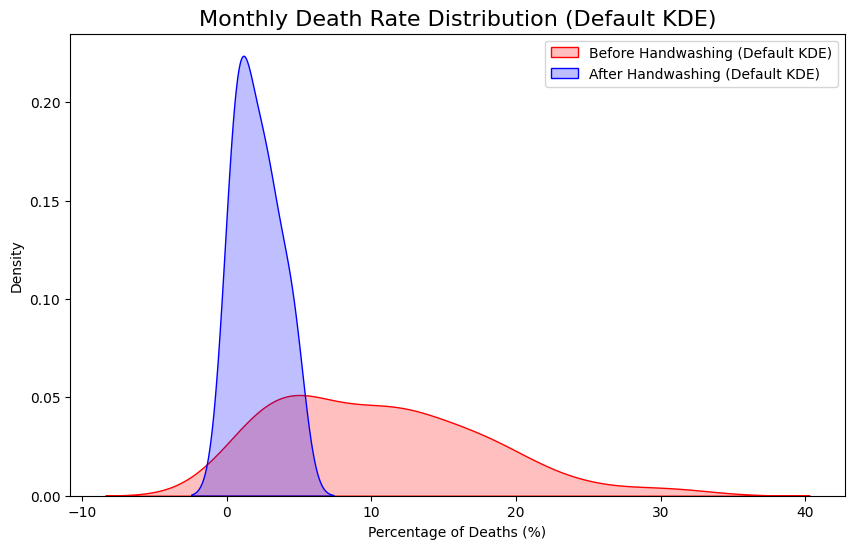

Weakness: The default KDE can extend into negative percentage values, which is unrealistic.


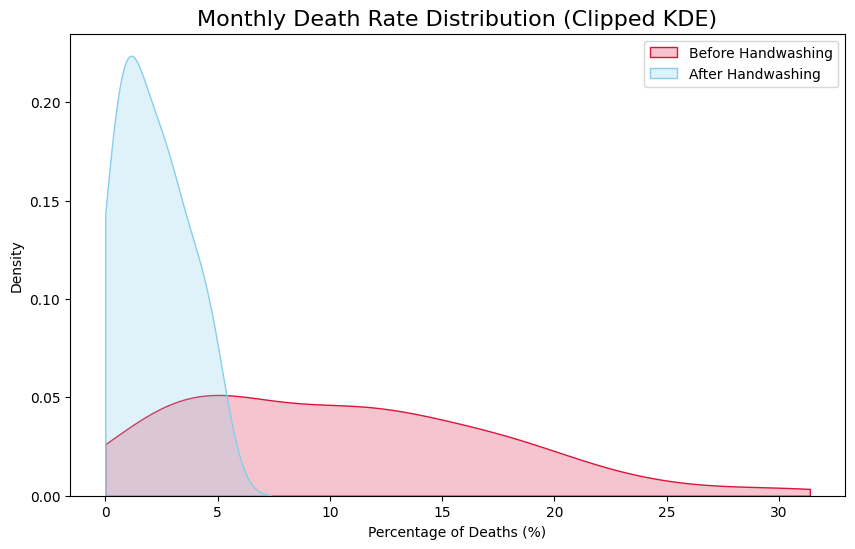

In [17]:
plt.figure(figsize=(10,6), dpi=100)

# KDE plot before handwashing (default parameters)
sns.kdeplot(df_before_handwashing['pct_deaths'], fill=True, color='red', label='Before Handwashing (Default KDE)')
sns.kdeplot(df_after_handwashing['pct_deaths'], fill=True, color='blue', label='After Handwashing (Default KDE)')
plt.title('Monthly Death Rate Distribution (Default KDE)', fontsize=16)
plt.xlabel('Percentage of Deaths (%)')
plt.ylabel('Density')
plt.legend()
plt.show()

print("Weakness: The default KDE can extend into negative percentage values, which is unrealistic.")

plt.figure(figsize=(10,6), dpi=100)

# KDE plot with clipping
# Find the maximum percentage death for clipping
max_pct_deaths = df_monthly['pct_deaths'].max()

sns.kdeplot(df_before_handwashing['pct_deaths'], fill=True, color='crimson', label='Before Handwashing', clip=(0, max_pct_deaths))
sns.kdeplot(df_after_handwashing['pct_deaths'], fill=True, color='skyblue', label='After Handwashing', clip=(0, max_pct_deaths))

plt.title('Monthly Death Rate Distribution (Clipped KDE)', fontsize=16)
plt.xlabel('Percentage of Deaths (%)')
plt.ylabel('Density')
plt.legend()
plt.show()

### Use a T-Test to Show Statistical Significance

**Challenge**: Use a t-test to determine if the differences in the means are statistically significant or purely due to chance.

If the p-value is less than 1% then we can be 99% certain that handwashing has made a difference to the average monthly death rate.

* Import `stats` from scipy
* Use the [`.ttest_ind()` function](https://docs.scipy.org/]doc/scipy/reference/generated/scipy.stats.ttest_ind.html) to calculate the t-statistic and the p-value
* Is the difference in the average proportion of monthly deaths statistically significant at the 99% level?



In [18]:
from scipy import stats

# Perform independent t-test
t_statistic, p_value = stats.ttest_ind(df_before_handwashing['pct_deaths'],
                                       df_after_handwashing['pct_deaths'])

print(f"T-statistic: {t_statistic:.2f}")
print(f"P-value: {p_value:.4f}")

# Check for statistical significance at the 99% level
if p_value < 0.01:
    print("\nConclusion: The difference in the average proportion of monthly deaths is statistically significant at the 99% level.")
    print("This suggests that handwashing had a significant impact on reducing the death rate.")
else:
    print("\nConclusion: The difference in the average proportion of monthly deaths is not statistically significant at the 99% level.")

T-statistic: 5.51
P-value: 0.0000

Conclusion: The difference in the average proportion of monthly deaths is statistically significant at the 99% level.
This suggests that handwashing had a significant impact on reducing the death rate.


What do you conclude from your analysis, Doctor? 😊

<img src=https://i.imgur.com/rvjNVzQ.gif>